In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# Tải dữ liệu
from google.colab import files
files.upload()    # student_scores.csv

Saving student_scores.csv to student_scores.csv


{'student_scores.csv': b'hours,attendance,midterm_score,final_score\r\n1,60,5,6\r\n2,65,5.5,6.5\r\n3,70,6,7\r\n4,75,6.5,7.5\r\n5,80,7,8\r\n6,85,7.5,8.5\r\n7,90,8,9\r\n8,92,8.5,9.2\r\n2,60,5,6.2\r\n3,68,5.8,6.8\r\n4,72,6.3,7.2\r\n5,78,6.8,7.8\r\n6,82,7.3,8.2\r\n7,88,7.8,8.8\r\n8,95,8.8,9.5\r\n1,55,4.5,5.5\r\n2,62,5.2,6.3\r\n3,66,5.7,6.7\r\n4,74,6.4,7.3\r\n5,79,6.9,7.9\r\n'}

- hours: số giờ học
- attendance: % đi học
- midterm_score: điểm giữa kỳ
- final_score: điểm cuối kỳ (target)

In [3]:
# Load data
df = pd.read_csv("student_scores.csv")
df

,hours,attendance,midterm_score,final_score
0,1,60,5.0,6.0
1,2,65,5.5,6.5
2,3,70,6.0,7.0
3,4,75,6.5,7.5
4,5,80,7.0,8.0
5,6,85,7.5,8.5
6,7,90,8.0,9.0
7,8,92,8.5,9.2
8,2,60,5.0,6.2
9,3,68,5.8,6.8


# **1. Linear Regression (1 biến)**

**Đề bài: Dự đoán final_score dựa vào hours**

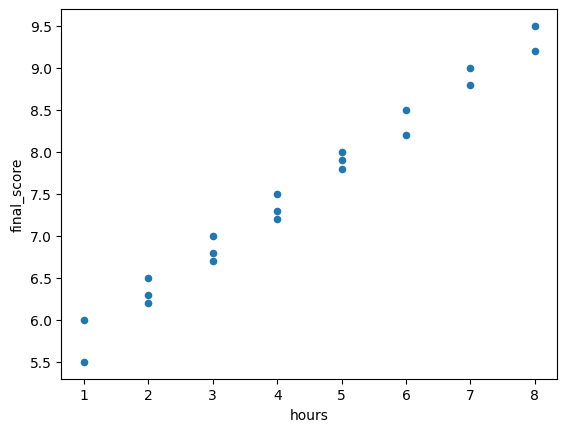

In [4]:
# Vẽ biểu đồ phân tán (scatter plot) để biểu diễn mối quan hệ giữa 2 bên
df.plot.scatter(
    x = 'hours',
    y = 'final_score'
)
plt.show()


Áp dụng mô hình tuyến tính

In [5]:
# Tạo mô hình
model = LinearRegression()

# Xác định biến
    # x là hours (số giờ học)
x = df[['hours']]
    # y là final_score (điểm cuối kỳ)
y = df['final_score']

# Huấn luyện mô hình
model.fit(x, y)

LinearRegression()

In [7]:
# Tìm độc dốc (coef) - biến a trong y = ax + b
print("Độ dốc (biến a):", model.coef_)
# Tìm hệ số chặn (intercept) - biến b trong y = ax + b
print("Hệ số chặn (biến b):", model.intercept_)

Độ dốc (biến a): [0.51334056]
Hệ số chặn (biến b): 5.28763557483731


In [8]:
# corr(): tính hệ số tương quan giữa 2 Series
df['final_score'].corr(df['hours'])

np.float64(0.9916058156731933)

Best of fit

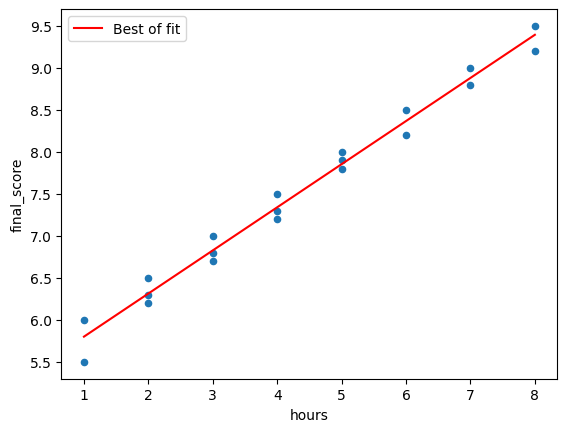

In [9]:
# Vẽ biểu đồ phân tán (scatter plot) để biểu diễn mối quan hệ giữa 2 bên
df.plot.scatter(
    x = 'hours',
    y = 'final_score'
)
# Tạo 1 mảng x từ nhỏ nhất đến lớn nhất (x của đường hồi quy - best of fit)
x_line = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
# Tính các giá trị y tương ứng với x_line vừa tạo: y = ax + b
y_line = model.coef_[0] * x_line + model.intercept_

# Vẽ đường best of fit
plt.plot(x_line, y_line, color='red', label='Best of fit')
plt.legend() # hiện chú thích cho các đường cột, điểm,...
plt.show()

Train - test mô hình

In [12]:
from sklearn.model_selection import train_test_split

# Split data (chia dữ liệu để train (80%) và test (20%))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# Tạo model mới từ x, y sau khi train
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [13]:
# test
y_pred = model.predict(x_test)
print("Prediction:", y_pred[:5])

Prediction: [7.3375 6.8125 5.7625 8.3875]


Vẽ lại biểu đồ <br>
- Chấm xanh: dữ liệu thật
- Đường đỏ: mô hình học được

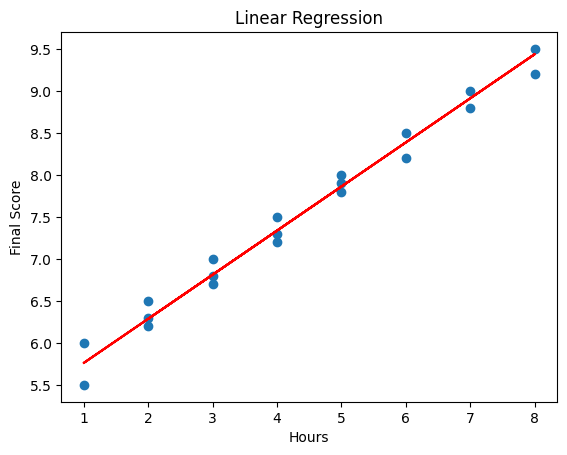

In [15]:
plt.scatter(x, y)  # dữ liệu thật
plt.plot(x, model.predict(x), color='red')  # đường hồi quy
plt.xlabel("Hours")
plt.ylabel("Final Score")
plt.title("Linear Regression")
plt.show()

Đánh giá mô hình

- MSE (Mean Squared Error):
    + Sai số trung bình
    + Càng nhỏ càng tốt
- R² (R-squared):
    + Độ phù hợp của mô hình
    + Gần 1 → rất tốt

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 0.02328125000000008
R2: 0.9634445534838075


# **2. Linear Regression đa biến**

In [17]:
X = df[["hours", "attendance", "midterm_score"]]
y = df["final_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Prediction:", y_pred[:5])

Prediction: [6.0758415  5.58459613 6.82443478 8.9609815 ]


In [18]:
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [0.06233217 0.07799562 0.07787017]
Bias: 0.8820889944745494


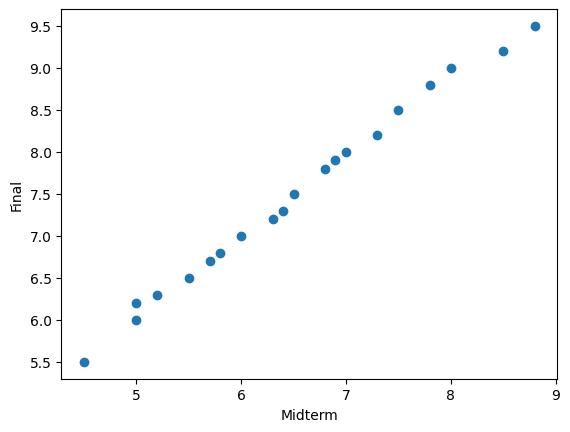

In [19]:
plt.scatter(df["midterm_score"], df["final_score"])
plt.xlabel("Midterm")
plt.ylabel("Final")
plt.show()

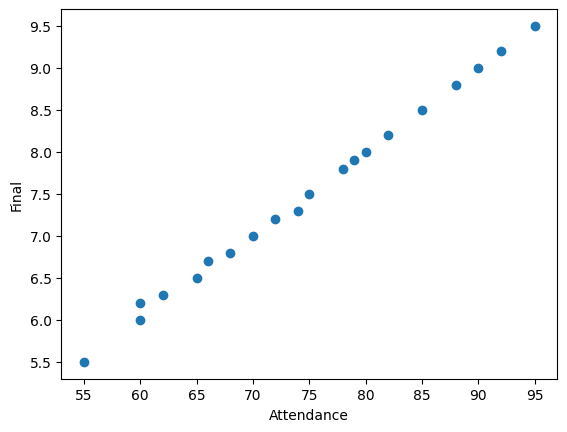

In [21]:
plt.scatter(df["attendance"], df["final_score"])
plt.xlabel("Attendance")
plt.ylabel("Final")
plt.show()

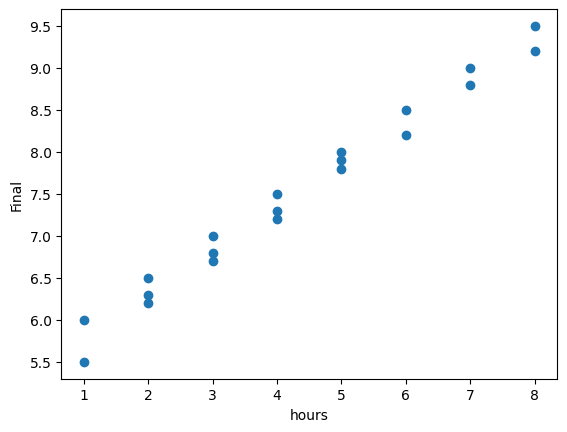

In [22]:
plt.scatter(df["hours"], df["final_score"])
plt.xlabel("hours")
plt.ylabel("Final")
plt.show()

# **LUYỆN TẬP**

**Đề bài: Dự đoán giá xe ô tô và những yếu tố ảnh hưởng đến giá xe**

In [24]:
# Tải dữ liệu
from google.colab import files
files.upload()    # car_price_data.csv

Saving car_price_data.csv to car_price_data.csv


{'car_price_data.csv': b'engine_size,horsepower,age,mileage,price\r\n1.0,70,10,120000,15000\r\n1.2,80,8,100000,18000\r\n1.4,90,7,90000,20000\r\n1.6,110,5,70000,25000\r\n2.0,150,3,50000,32000\r\n2.5,180,2,30000,40000\r\n3.0,220,1,20000,50000\r\n1.1,75,9,110000,16000\r\n1.3,85,8,95000,19000\r\n1.5,100,6,80000,23000\r\n1.8,130,4,60000,28000\r\n2.2,160,3,45000,35000\r\n2.8,200,2,25000,45000\r\n3.2,240,1,15000,55000\r\n1.0,65,11,130000,14000\r\n1.2,78,9,105000,17500\r\n1.4,88,7,88000,21000\r\n1.6,105,6,75000,24000\r\n2.0,140,4,55000,31000\r\n2.4,170,3,40000,37000\r\n3.0,210,2,22000,48000\r\n1.1,72,10,115000,15500\r\n1.3,82,8,97000,18500\r\n1.5,98,6,82000,22500\r\n1.8,125,5,65000,27000\r\n2.2,155,3,48000,34000\r\n2.6,190,2,30000,43000\r\n3.1,230,1,18000,52000\r\n1.0,68,10,125000,14500\r\n1.2,79,9,102000,17800\r\n1.4,92,7,89000,20500\r\n1.6,108,5,72000,25500\r\n2.0,145,4,58000,31500\r\n2.3,165,3,42000,36500\r\n2.9,205,2,26000,47000\r\n3.3,245,1,14000,56000\r\n1.1,74,9,112000,15800\r\n1.3,84,8

In [26]:
df = pd.read_csv("car_price_data.csv")
df

,engine_size,horsepower,age,mileage,price
0,1.0,70,10,120000,15000
1,1.2,80,8,100000,18000
2,1.4,90,7,90000,20000
3,1.6,110,5,70000,25000
4,2.0,150,3,50000,32000
5,2.5,180,2,30000,40000
6,3.0,220,1,20000,50000
7,1.1,75,9,110000,16000
8,1.3,85,8,95000,19000
9,1.5,100,6,80000,23000


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   engine_size  44 non-null     float64
 1   horsepower   44 non-null     int64  
 2   age          44 non-null     int64  
 3   mileage      44 non-null     int64  
 4   price        44 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 1.8 KB


**Trực quan hóa dữ liệu**

engine_size vs price <br>
- engine_size tăng thì price tăng
- Quan hệ gần tuyến tính

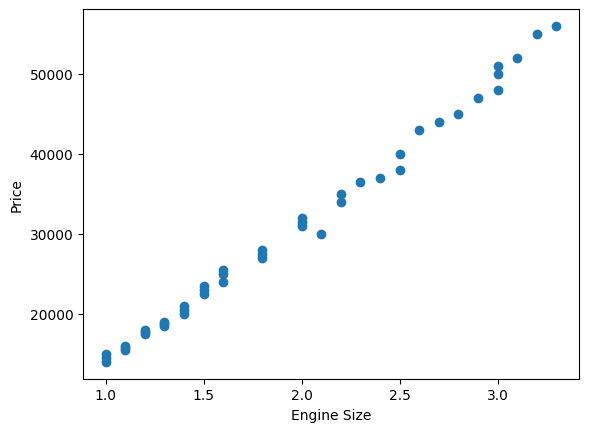

In [29]:
plt.scatter(df["engine_size"], df["price"])
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()

horsepower vs price <br>
=> Mã lực càng cao thì giá càng cao

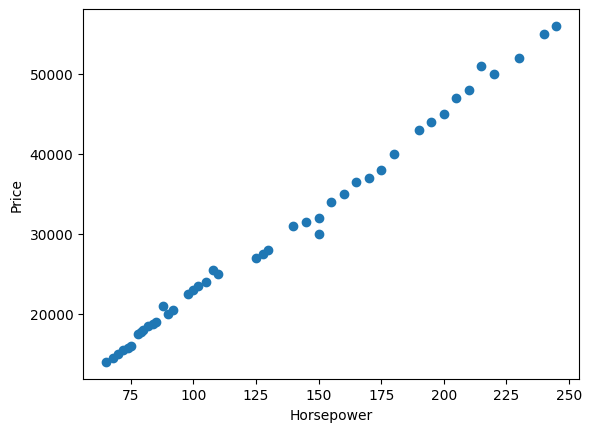

In [30]:
plt.scatter(df["horsepower"], df["price"])
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()

mileage vs price <br>
=> xe đi nhiều thì mất giá

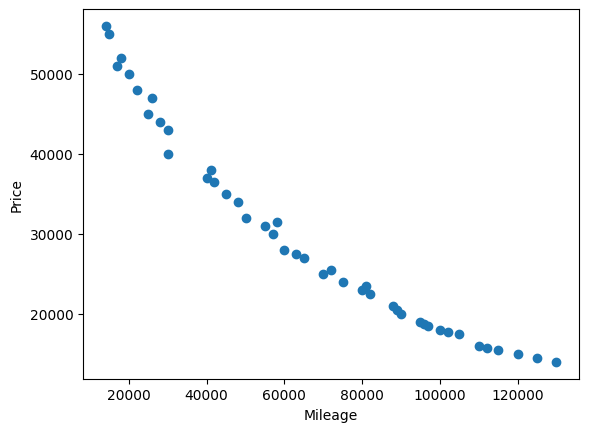

In [31]:
plt.scatter(df["mileage"], df["price"])
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

**Train với engine_size**

In [33]:
X = df[["engine_size"]]
y = df["price"]

model = LinearRegression()
model.fit(X, y)

LinearRegression()

- Nhận xét:
    + Đường thẳng fit khá tốt
    + Nhưng chưa chính xác hoàn toàn
- Vì: Giá xe không chỉ phụ thuộc engine

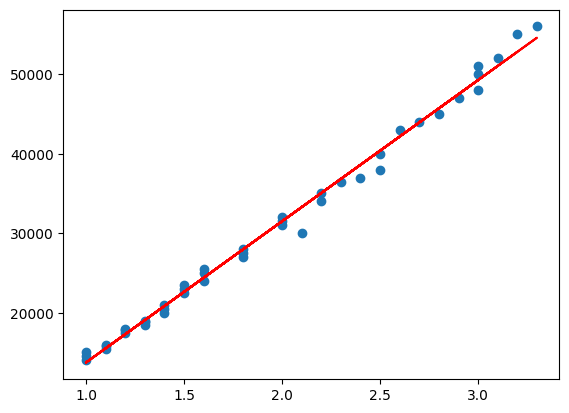

In [35]:
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')
plt.show()

**Đánh giá**

In [36]:
y_pred = model.predict(X)

print("MSE:", mean_squared_error(y, y_pred))
print("R2:", r2_score(y, y_pred))

MSE: 989470.2612166354
R2: 0.9936053734430268
